In [1]:

# SEKCJA 1: IMPORTY, KONFIGURACJA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from sklearn.model_selection import (train_test_split, StratifiedKFold, 
                                     StratifiedGroupKFold, GroupShuffleSplit, cross_validate)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             f1_score, balanced_accuracy_score, silhouette_score, 
                             davies_bouldin_score)

# Konfiguracja środowiska
os.environ["LOKY_MAX_CPU_COUNT"] = "1"
plt.rcParams['text.usetex'] = False  
sns.set_theme(style="whitegrid")      
RANDOM_SEED = 42

# 1. Wczystanie i czyszczenie danych

df = pd.read_csv('motors.csv')

# Usuwamy kolumny techniczne
df = df.drop(columns=[c for c in df.columns if c.startswith("is_") or "Unnamed" in c], errors="ignore")

# Mapowanie klas na format naukowy
viz_mapping = {
    'Healthy': 'Healthy State',
    'Mech_Damage': 'Mechanical Fault',
    'Elec_Damage': 'Electrical Fault',
    'Mech_Elec_Damage': 'Mixed Fault Condition'
}
df['Class'] = df['Class'].replace(viz_mapping)
df = df.dropna(subset=['Class'])

# 2. Definicja cech i obsługa błędów

current_cols = [c for c in df.columns if "CURRENT" in c.upper()]
roto_cols = [c for c in df.columns if "ROTO" in c.upper()]
feature_cols = current_cols + roto_cols

if not feature_cols:
    raise ValueError("Błąd: Nie znaleziono cech pasujących do wzorca CURRENT/ROTO!")

# Czyszczenie Inf/NaN 
X = df[feature_cols].replace([np.inf, -np.inf], np.nan)
y = df["Class"]

valid_mask = X.dropna().index
X = X.loc[valid_mask]
y = y.loc[valid_mask]

# Identyfikacja grup
groups = df.loc[valid_mask, 'Source_File'] if 'Source_File' in df.columns else None

# Kodowanie etykiet
le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_  

# 3. Definicja modeli i pipeline

class XGBClassifierBalanced(XGBClassifier):
    def fit(self, X, y, **kwargs):
        w = compute_sample_weight(class_weight='balanced', y=y)
        return super().fit(X, y, sample_weight=w, **kwargs)

def get_stacking_ensemble():
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    estimators = [
        ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_SEED)),
        ('svm', make_pipeline(StandardScaler(), SVC(probability=True, class_weight='balanced', random_state=RANDOM_SEED))),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ]
    return StackingClassifier(
        estimators=estimators, 
        final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
        cv=inner_cv,
        stack_method='predict_proba'
    )

MODELS_REQUIRING_SCALING = (LogisticRegression, SVC, KNeighborsClassifier, StackingClassifier)

def build_pipeline(model, use_pca=False, select_features=False):
    steps = []
    
    if use_pca or isinstance(model, MODELS_REQUIRING_SCALING):
        steps.append(('scaler', StandardScaler()))
        
    if select_features:
        steps.append(('selector', SelectFromModel(
            RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_SEED),
            max_features=15
        )))
    
    if use_pca:
        steps.append(('pca', PCA(n_components=0.9, random_state=RANDOM_SEED)))

    steps.append(('clf', model))
    return Pipeline(steps)

def evaluate_model(model, X_data, y_data, groups=None, use_pca=False, select_features=False):
    if isinstance(model, XGBClassifier) and not isinstance(model, XGBClassifierBalanced):
        model = XGBClassifierBalanced(**model.get_params())

    pipeline = build_pipeline(model, use_pca=use_pca, select_features=select_features)
    
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED) if groups is not None else \
         StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        
    cv_results = cross_validate(
        pipeline, X_data, y_data,
        groups=groups,
        cv=cv,
        scoring=['balanced_accuracy', 'f1_macro'],
        n_jobs=-1
    )
    
    return {
        "BACC_mean": np.mean(cv_results['test_balanced_accuracy']),
        "BACC_std": np.std(cv_results['test_balanced_accuracy']),
        "F1_mean": np.mean(cv_results['test_f1_macro']),
        "F1_std": np.std(cv_results['test_f1_macro'])
    }

def run_experiment(model, X_train, X_test, y_train, y_test, use_pca=False):
    pipeline = build_pipeline(model, use_pca=use_pca)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    return {
        "bacc": balanced_accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred, average='macro'),
        "y_pred": y_pred
    }

# 4. Raport początkowy

print(f"Samples: {X.shape[0]} | Features: {X.shape[1]}")
print(f"Unique motors (groups): {groups.nunique() if groups is not None else 'N/A (Single recording per class)'}")
print(f"Class distribution:\n{y.value_counts(normalize=True).map('{:.1%}'.format)}")
print(f"Encoded classes: {list(enumerate(class_names))}")
print("-" * 30)

new_files = sorted(glob.glob('Faulty-*.csv') + glob.glob('Healthy-*.csv'))

Samples: 184 | Features: 26
Unique motors (groups): N/A (Single recording per class)
Class distribution:
Class
Electrical Fault         25.0%
Healthy State            25.0%
Mixed Fault Condition    25.0%
Mechanical Fault         25.0%
Name: proportion, dtype: object
Encoded classes: [(0, 'Electrical Fault'), (1, 'Healthy State'), (2, 'Mechanical Fault'), (3, 'Mixed Fault Condition')]
------------------------------



PCA SEPARABILITY METRICS
Silhouette Score (PCA Space): 0.0764
Davies-Bouldin Index (PCA Space): 3.4024
Explained Variance (PC1 + PC2): 59.50%


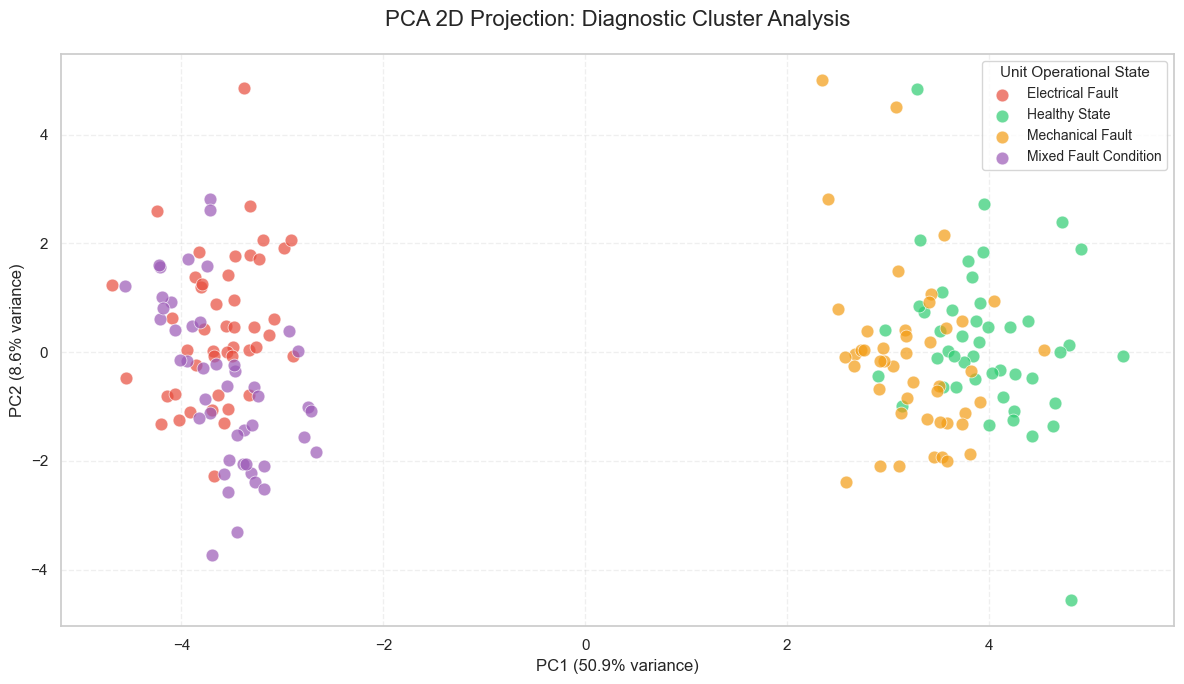

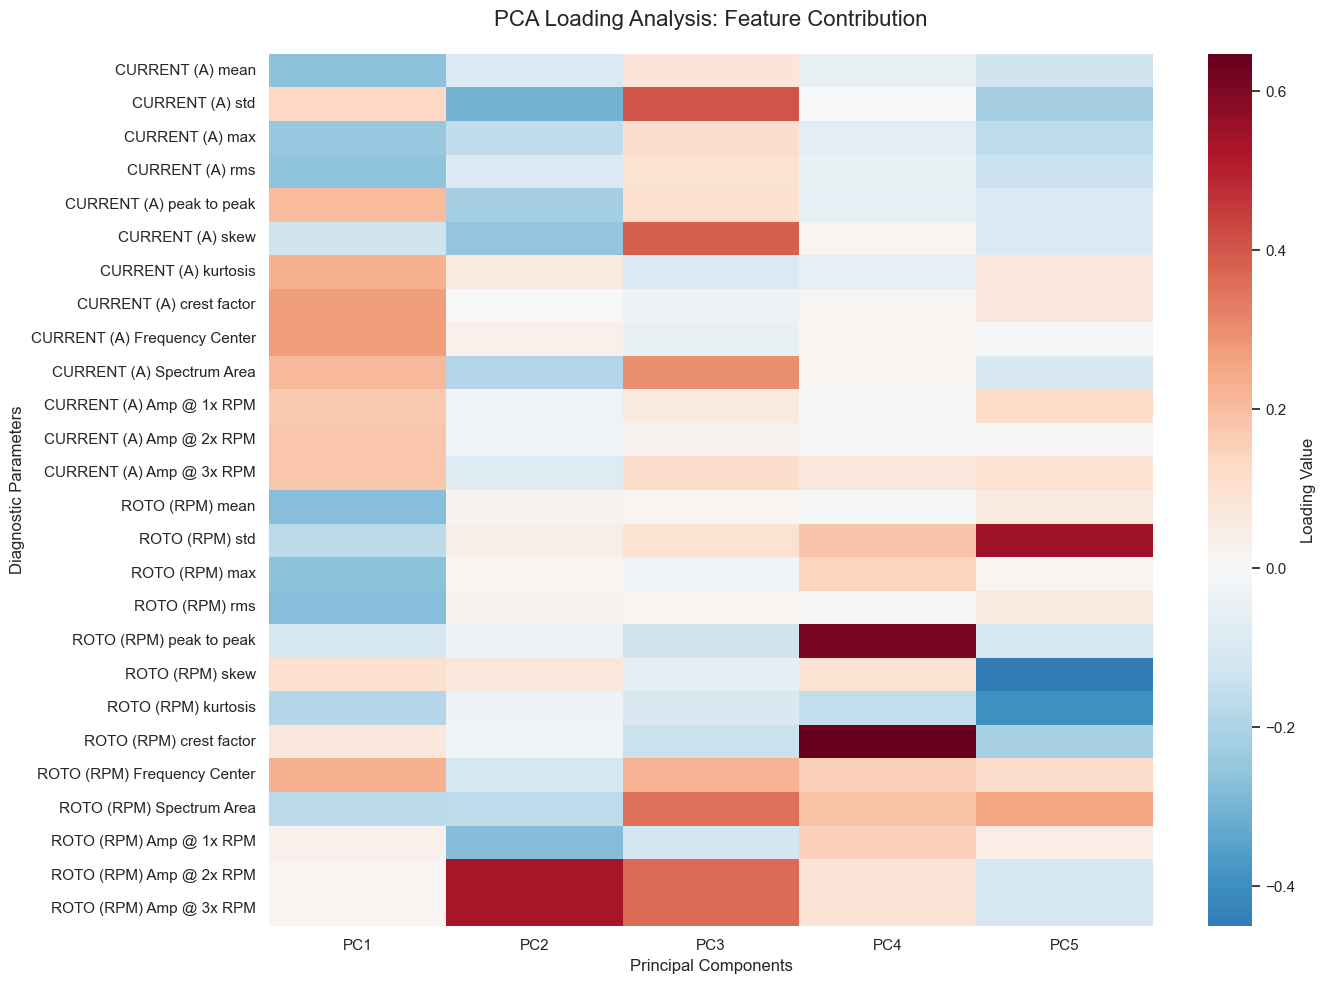

In [2]:
# SEKCJA 2: ANALIZA PCA I METRYKI SEPAROWALNOŚCI

# 1. TRANSFORMACJA PCA
scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X) 

pca_viz = PCA(n_components=0.9, svd_solver='full', random_state=RANDOM_SEED)
X_pca_viz = pca_viz.fit_transform(X_scaled_viz)
explained_var = pca_viz.explained_variance_ratio_

# 2. METRYKI SEPAROWALNOŚCI
sil = silhouette_score(X_pca_viz, y_encoded)
db = davies_bouldin_score(X_pca_viz, y_encoded)

print("\nPCA SEPARABILITY METRICS")
print(f"Silhouette Score (PCA Space): {sil:.4f}")
print(f"Davies-Bouldin Index (PCA Space): {db:.4f}")
print(f"Explained Variance (PC1 + PC2): {sum(explained_var[:2]):.2%}")

# 3. WIZUALIZACJA PROJEKCJI 2D
plt.figure(figsize=(12, 7))

colors = {
    'Healthy State': '#2ecc71',
    'Mechanical Fault': '#f39c12',
    'Electrical Fault': '#e74c3c',
    'Mixed Fault Condition': '#9b59b6'
}

for cls in class_names:
    mask = (y == cls)
    plt.scatter(
        X_pca_viz[mask, 0], X_pca_viz[mask, 1],
        c=colors.get(cls, '#000000'), label=cls, 
        s=85, alpha=0.7, edgecolors='white', linewidth=0.6, zorder=3
    )

plt.title("PCA 2D Projection: Diagnostic Cluster Analysis", fontsize=16, pad=20)
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)", fontsize=12)
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)", fontsize=12)
plt.legend(title="Unit Operational State", title_fontsize='11', fontsize='10', loc='best', frameon=True)
plt.grid(alpha=0.3, linestyle='--', zorder=0)
plt.tight_layout()
plt.savefig("pca_2d_projection.png", dpi=200)
plt.show()

# 4. ANALIZA LOADINGS
formatted_index = [col.replace('_', ' ') for col in X.columns]
loadings = pd.DataFrame(
    pca_viz.components_.T,
    index=formatted_index,
    columns=[f"PC{i+1}" for i in range(pca_viz.n_components_)]
)

plt.figure(figsize=(14, 10))
sns.heatmap(loadings.iloc[:, :5], cmap="RdBu_r", center=0, annot=False, cbar_kws={'label': 'Loading Value'})
plt.title("PCA Loading Analysis: Feature Contribution", fontsize=16, pad=20)
plt.xlabel("Principal Components", fontsize=12)
plt.ylabel("Diagnostic Parameters", fontsize=12)
plt.tight_layout()
plt.savefig("pca_loading_analysis.png", dpi=200)
plt.show()

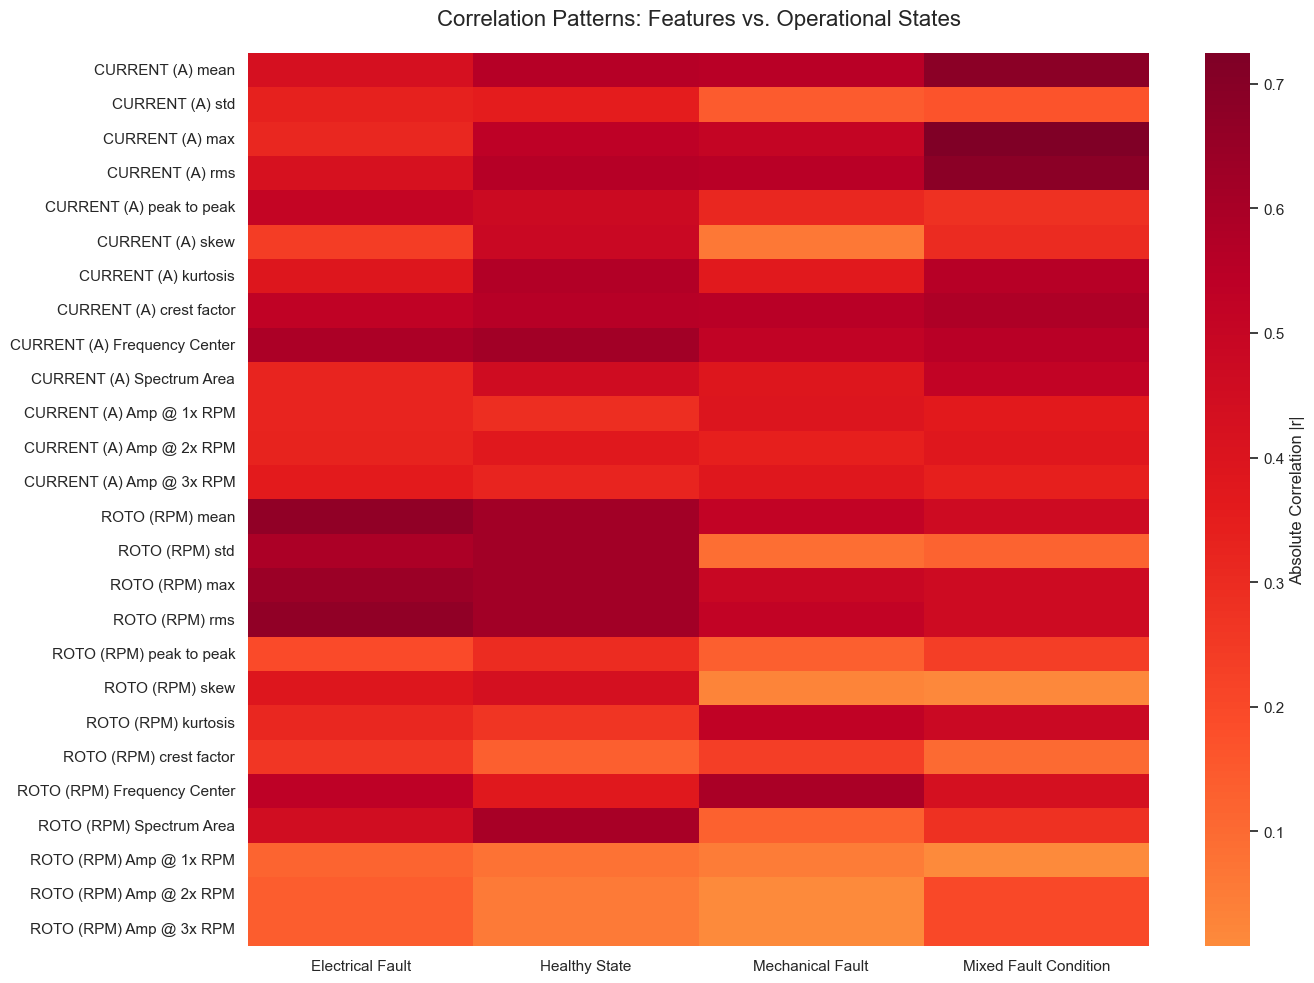

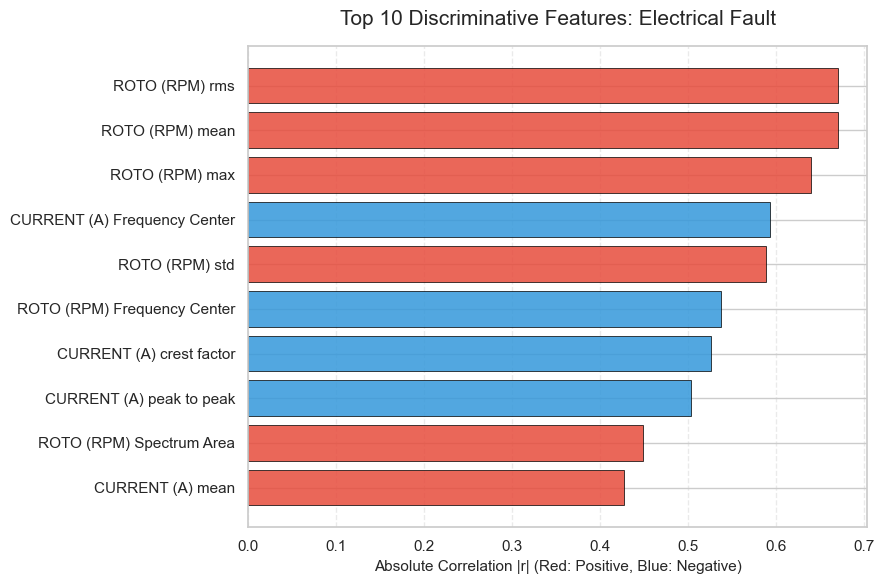

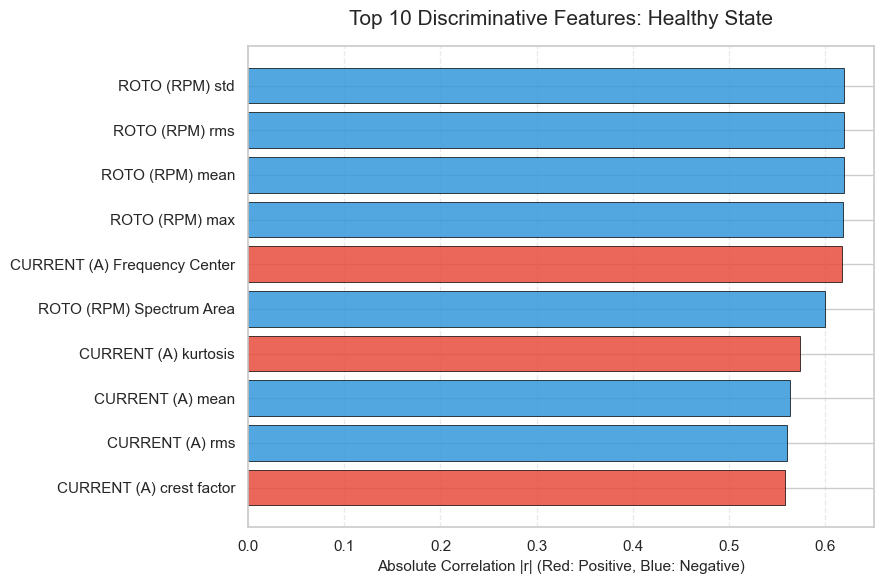

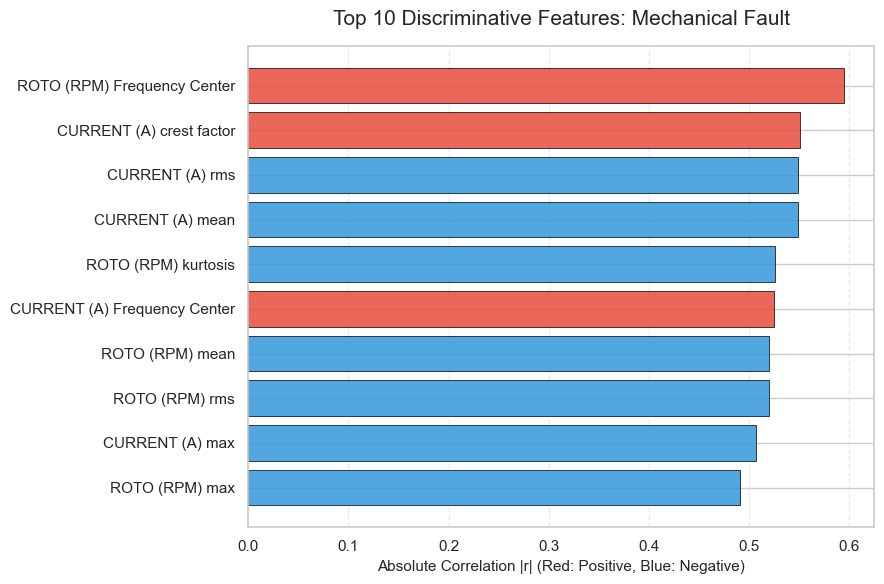

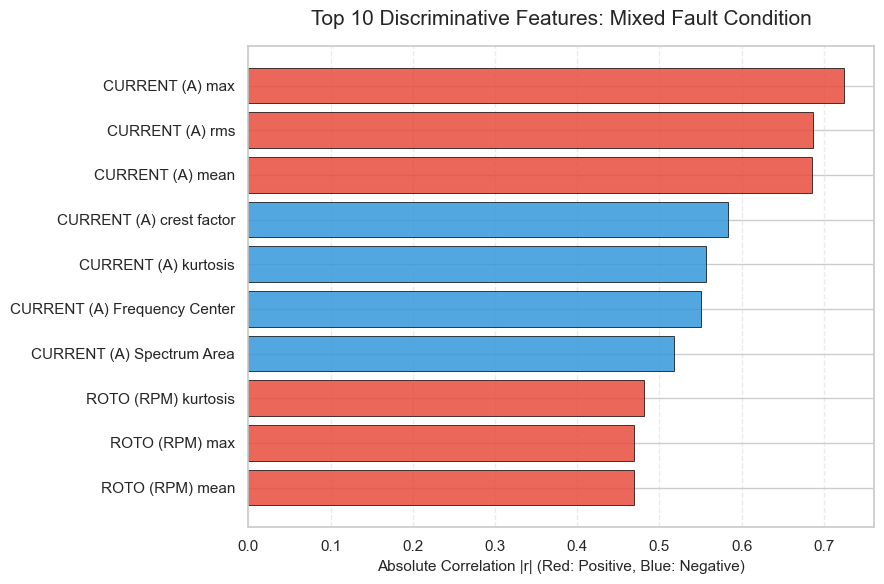

In [3]:
# SEKCJA 3: ANALIZA WZORCÓW KORELACYJNYCH

# 1. Maciec korelacji
y_dummies = pd.get_dummies(y, prefix='is')
df_analysis = pd.concat([X, y_dummies], axis=1)

correlation_matrix = df_analysis.corr().loc[feature_cols, y_dummies.columns]
correlation_matrix.columns = [col.replace('is_', '').replace('_', ' ') for col in correlation_matrix.columns]
correlation_matrix.index = [idx.replace('_', ' ') for idx in correlation_matrix.index]

# 2. Wizualizacja
plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix.abs(), cmap="YlOrRd", center=0, annot=False, 
    cbar_kws={'label': 'Absolute Correlation |r|'}
)
plt.title("Correlation Patterns: Features vs. Operational States", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=200)
plt.show()

# 3. Analiza top 10
top_n = 10
for class_name in correlation_matrix.columns:
    top_features = correlation_matrix[class_name].abs().sort_values(ascending=False).head(top_n)
    signs = correlation_matrix.loc[top_features.index, class_name]
    
    plt.figure(figsize=(9, 6))
    bar_colors = ['#e74c3c' if val > 0 else '#3498db' for val in signs]
    
    plt.barh(
        top_features.index, top_features.values, 
        color=bar_colors, edgecolor='black', linewidth=0.6, alpha=0.85
    )
    
    plt.title(f"Top {top_n} Discriminative Features: {class_name}", fontsize=15, pad=15)
    plt.xlabel("Absolute Correlation |r| (Red: Positive, Blue: Negative)", fontsize=11)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
    
    plt.tight_layout()
    plt.savefig(f"feature_importance_{class_name.replace(' ', '_')}.png", dpi=200)
    plt.show()


Experiment: Mechanical vs Mixed State
Balanced Accuracy: 1.0000


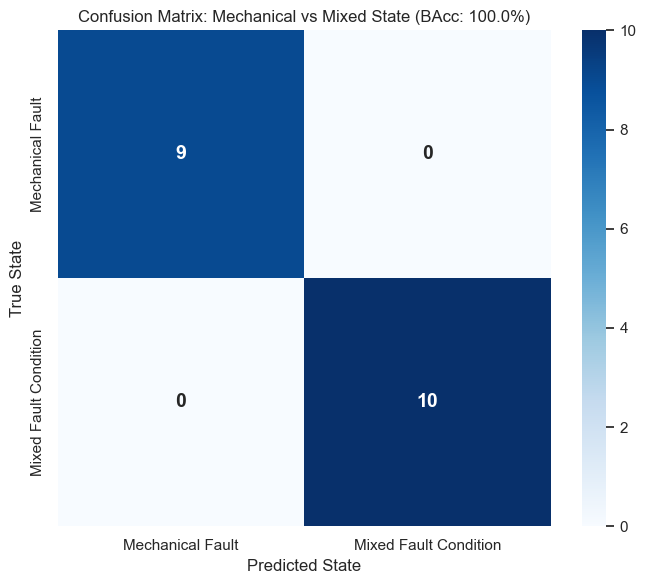


Group-Aware BACC (Mechanical/Mixed Analysis): 1.0000 (+/- 0.0000)


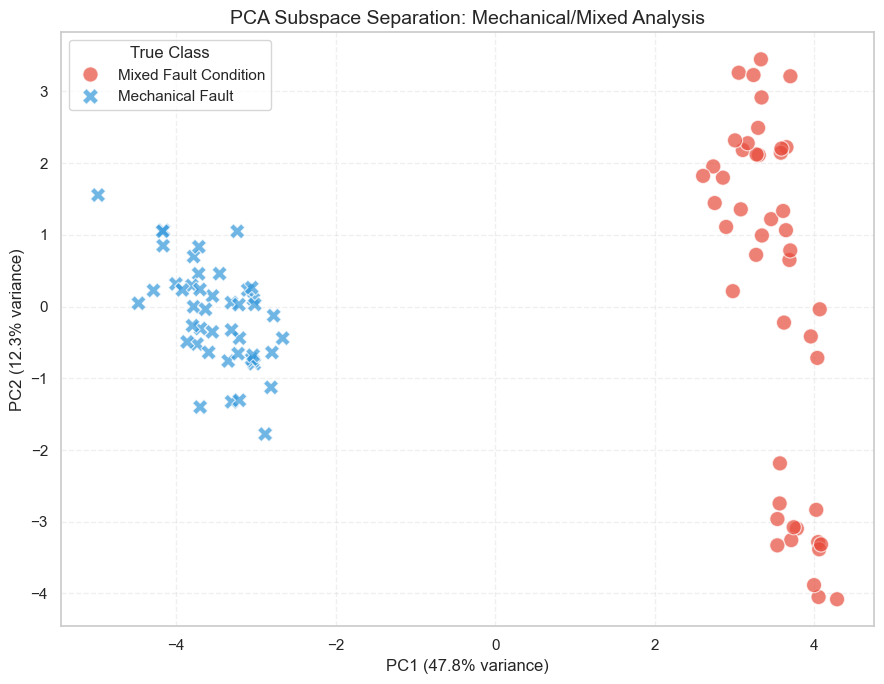


Experiment: Electrical vs Mixed State
Balanced Accuracy: 1.0000


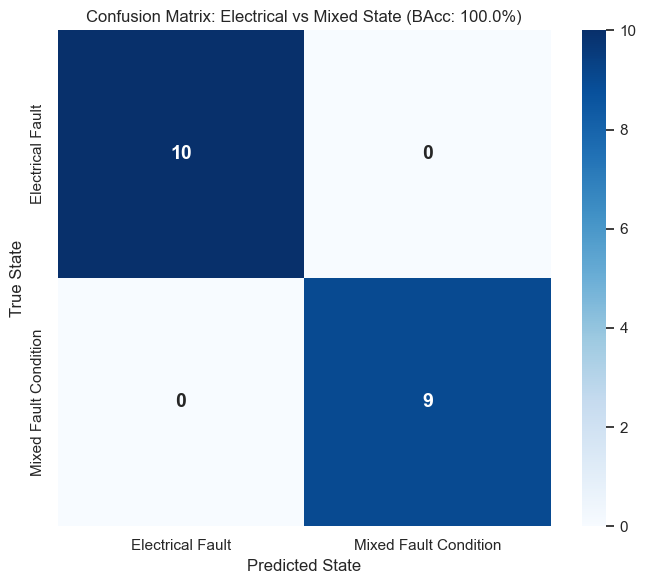


Group-Aware BACC (Electrical/Mixed Analysis): 1.0000 (+/- 0.0000)


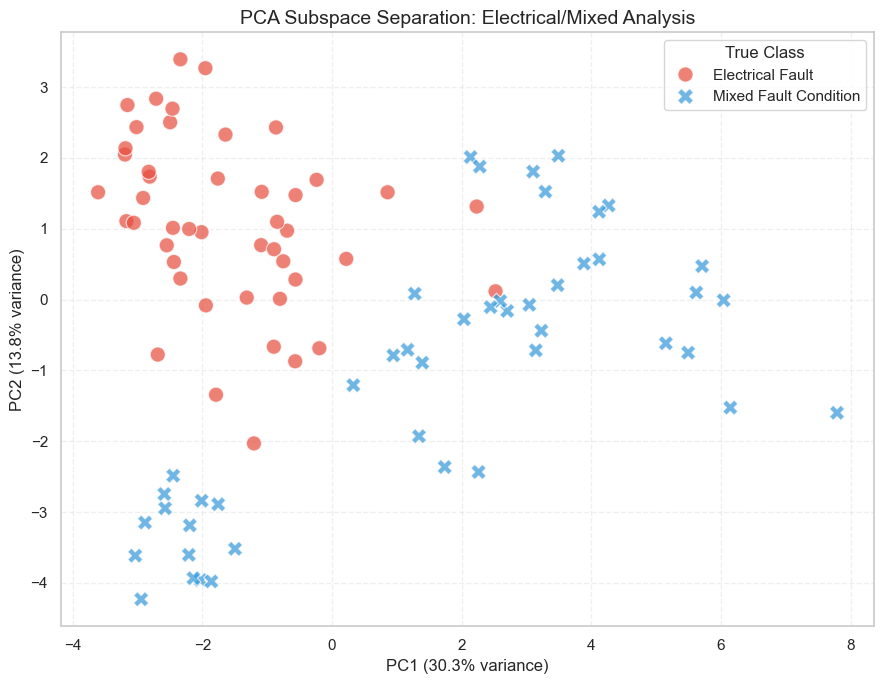

In [4]:
# SEKCJA 4: ANALIZA PODGRUP I SEPAROWALNOŚCI

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix

def analyze_subgroup(df_input, features, target_classes, experiment_name):
    # 1. Przygotowanie podgrupy danych
    df_sub = df_input[df_input["Class"].isin(target_classes)].copy()
    X_s = df_sub[features]
    y_s = df_sub["Class"]
    y_s_enc = le.transform(y_s)
    
    # Detekcja kolumny grupującej
    group_col_internal = next((col for col in ['Source_File', 'File', 'Motor_ID', 'ID'] if col in df_sub.columns), None)
    
    # 2. Podział danych z uwzględnieniem grup (zapobieganie wyciekowi danych)
    if group_col_internal:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
        train_idx, test_idx = next(gss.split(X_s, y_s_enc, groups=df_sub[group_col_internal]))
    else:
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
        train_idx, test_idx = next(skf.split(X_s, y_s_enc))

    X_train, X_test = X_s.iloc[train_idx], X_s.iloc[test_idx]
    y_train, y_test = y_s_enc[train_idx], y_s_enc[test_idx]

    # 3. Trenowanie i ewaluacja modelu (Stacking Ensemble)
    pipeline = build_pipeline(get_stacking_ensemble(), use_pca=False)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    bacc = balanced_accuracy_score(y_test, y_pred)
    print(f"\nExperiment: {experiment_name}")
    print(f"Balanced Accuracy: {bacc:.4f}")
    
    # 4. Wizualizacja macierzy błędów
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 6))
    display_labels = le.classes_[np.unique(y_s_enc)]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=display_labels, yticklabels=display_labels,
                annot_kws={"size": 14, "weight": "bold"})
    
    plt.title(f"Confusion Matrix: {experiment_name} (BAcc: {bacc*100:.1f}%)")
    plt.ylabel('True State')
    plt.xlabel('Predicted State')
    plt.tight_layout()
    plt.savefig(f"cm_{experiment_name.replace(' ', '_').lower()}.png", dpi=200)
    plt.show()

def verify_subgroup_separation(df_input, labels, title):
    df_sub = df_input[df_input["Class"].isin(labels)].copy()
    X_sub = df_sub[feature_cols]
    y_sub = df_sub["Class"]
    y_sub_enc = le.transform(y_sub)
    
    group_col_internal = next((col for col in ['Source_File', 'File', 'Motor_ID', 'ID'] if col in df_sub.columns), None)
            
    cv_strategy = StratifiedGroupKFold(n_splits=min(5, df_sub[group_col_internal].nunique()), shuffle=True, random_state=RANDOM_SEED) if group_col_internal else StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    cv_params = {'groups': df_sub[group_col_internal]} if group_col_internal else {}

    model_cv = build_pipeline(RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_SEED), use_pca=False)
    scores = cross_val_score(model_cv, X_sub, y_sub_enc, cv=cv_strategy, scoring='balanced_accuracy', **cv_params)
    
    print(f"\nGroup-Aware BACC ({title}): {scores.mean():.4f} (+/- {scores.std():.4f})")
    
    # Projekcja PCA
    pca_pipe = build_pipeline(LogisticRegression(), use_pca=True)
    pca_only = Pipeline(pca_pipe.steps[:-1])
    X_pca = pca_only.fit_transform(X_sub)
    
    plt.figure(figsize=(9, 7))
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_sub, style=y_sub, s=120, 
                    palette=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='white')
    
    exp_var = pca_only.named_steps['pca'].explained_variance_ratio_
    plt.title(f"PCA Subspace Separation: {title}", fontsize=14)
    plt.xlabel(f"PC1 ({exp_var[0]*100:.1f}% variance)")
    plt.ylabel(f"PC2 ({exp_var[1]*100:.1f}% variance)")
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(title="True Class")
    plt.tight_layout()
    plt.savefig(f"pca_subspace_{title.replace('/', '_').replace(' ', '_').lower()}.png", dpi=200)
    plt.show()

target_a = ["Mechanical Fault", "Mixed Fault Condition"]
analyze_subgroup(df, feature_cols, target_a, "Mechanical vs Mixed State")
verify_subgroup_separation(df, target_a, "Mechanical/Mixed Analysis")

target_b = ["Electrical Fault", "Mixed Fault Condition"]
analyze_subgroup(df, feature_cols, target_b, "Electrical vs Mixed State")
verify_subgroup_separation(df, target_b, "Electrical/Mixed Analysis")

C:\Users\Marek\AppData\Local\Temp\ipykernel_20196\3957966678.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_imp, x='Weight', y='Feature', palette='viridis', edgecolor='black', linewidth=0.6)


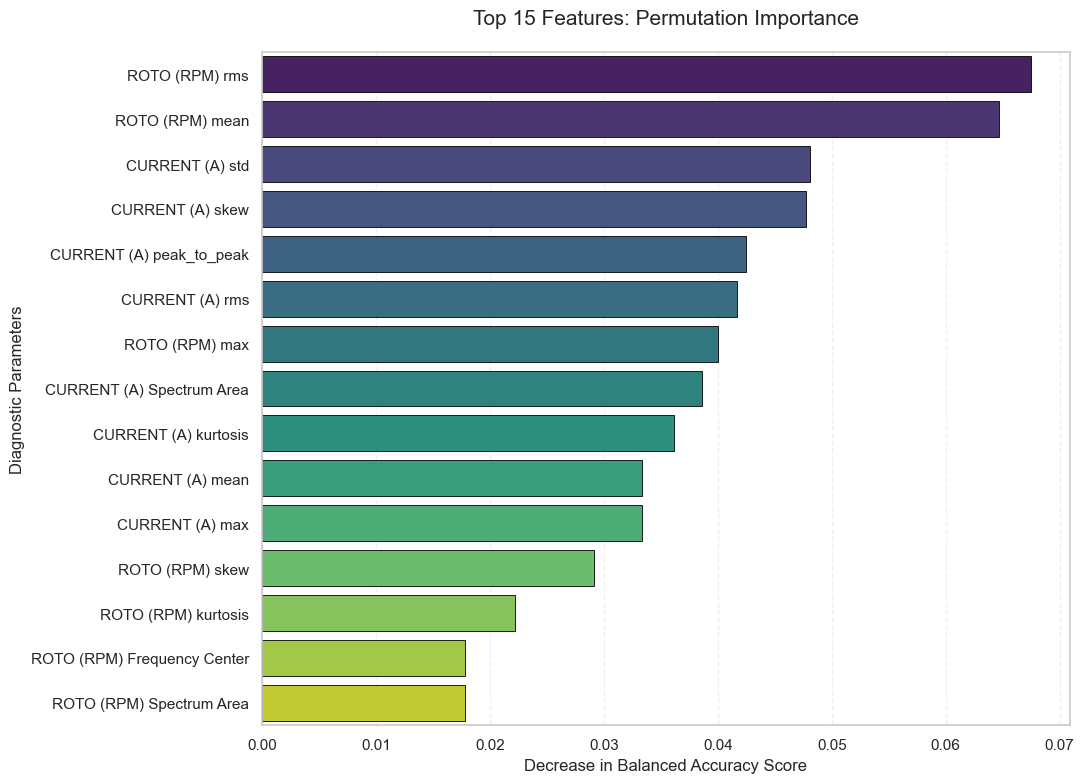


Evaluation of reduced feature set (Top 15)
Balanced Accuracy: 0.9167
Macro-F1 Score: 0.9143
                       precision    recall  f1-score   support

     Electrical Fault       1.00      1.00      1.00        10
        Healthy State       1.00      0.67      0.80         9
     Mechanical Fault       0.75      1.00      0.86         9
Mixed Fault Condition       1.00      1.00      1.00         9

             accuracy                           0.92        37
            macro avg       0.94      0.92      0.91        37
         weighted avg       0.94      0.92      0.92        37



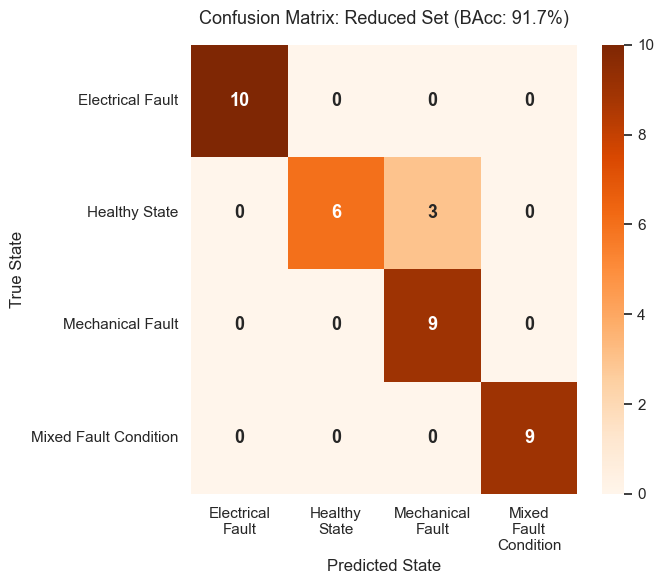

In [5]:
# SEKCJA 5: RANKING CECH I REDUKCJA

from sklearn.inspection import permutation_importance

# 1. Podział na grupy
group_col = next((col for col in ['Source_File', 'File', 'Motor_ID', 'ID'] if col in df.columns), None)

if group_col:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
    train_idx, test_idx = next(gss.split(X, y_encoded, groups=df[group_col]))
else:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    train_idx, test_idx = next(skf.split(X, y_encoded))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

# 2. Trening modelu
pipeline_fs = build_pipeline(get_stacking_ensemble(), use_pca=False)
pipeline_fs.fit(X_train, y_train)

# 3. OBliczacnie cech ważności
perm = permutation_importance(
    pipeline_fs, X_test, y_test, 
    n_repeats=10, random_state=RANDOM_SEED, n_jobs=-1, scoring='balanced_accuracy'
)

importances = pd.DataFrame({
    'Feature': feature_cols,
    'Weight': perm.importances_mean
}).sort_values(by='Weight', ascending=False)

TOP_N = 15
top_imp = importances.head(TOP_N)

# 4. Wizalizacja
plt.figure(figsize=(11, 8))
sns.barplot(data=top_imp, x='Weight', y='Feature', palette='viridis', edgecolor='black', linewidth=0.6)
plt.title(f"Top {TOP_N} Features: Permutation Importance", fontsize=15, pad=20)
plt.xlabel("Decrease in Balanced Accuracy Score", fontsize=12)
plt.ylabel("Diagnostic Parameters", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=200)
plt.show()

# 5. Ewaluacja na zredukowanym modelu
top_features_list = top_imp['Feature'].tolist()

print(f"\nEvaluation of reduced feature set (Top {TOP_N})")
metrics = run_experiment(
    get_stacking_ensemble(), 
    X_train[top_features_list], 
    X_test[top_features_list], 
    y_train, y_test, use_pca=False
)

print(f"Balanced Accuracy: {metrics['bacc']:.4f}")
print(f"Macro-F1 Score: {metrics['f1']:.4f}")
print(classification_report(y_test, metrics['y_pred'], target_names=class_names))

# 6. Macierz błędów dla zredukowanego stanu
cm = confusion_matrix(y_test, metrics['y_pred'])
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=[c.replace(' ', '\n') for c in class_names],
            yticklabels=class_names, annot_kws={"size": 13, "weight": "bold"})

plt.title(f"Confusion Matrix: Reduced Set (BAcc: {metrics['bacc']*100:.1f}%)", fontsize=13, pad=15)
plt.ylabel('True State')
plt.xlabel('Predicted State')
plt.tight_layout()
plt.savefig("confusion_matrix_reduced.png", dpi=200)
plt.show()

Running 5-Fold Stratified Group Cross-Validation...
Completed: Logistic Regression | Variant: Raw
Completed: Logistic Regression | Variant: PCA
Completed: SVM | Variant: Raw
Completed: SVM | Variant: PCA
Completed: Random Forest | Variant: Raw
Completed: Random Forest | Variant: PCA
Completed: XGBoost | Variant: Raw
Completed: XGBoost | Variant: PCA
Completed: Stacking Ensemble | Variant: Raw
Completed: Stacking Ensemble | Variant: PCA

PERFORMANCE MATRIX
Metric                                  F1           BACC
Model               Variant                              
Logistic Regression PCA      0.769 ± 0.052  0.771 ± 0.050
                    Raw      0.902 ± 0.067  0.903 ± 0.067
Random Forest       PCA      0.823 ± 0.117  0.827 ± 0.112
                    Raw      0.934 ± 0.039  0.935 ± 0.037
SVM                 PCA      0.802 ± 0.066  0.806 ± 0.064
                    Raw      0.884 ± 0.032  0.885 ± 0.031
Stacking Ensemble   PCA      0.829 ± 0.101  0.832 ± 0.098
                  

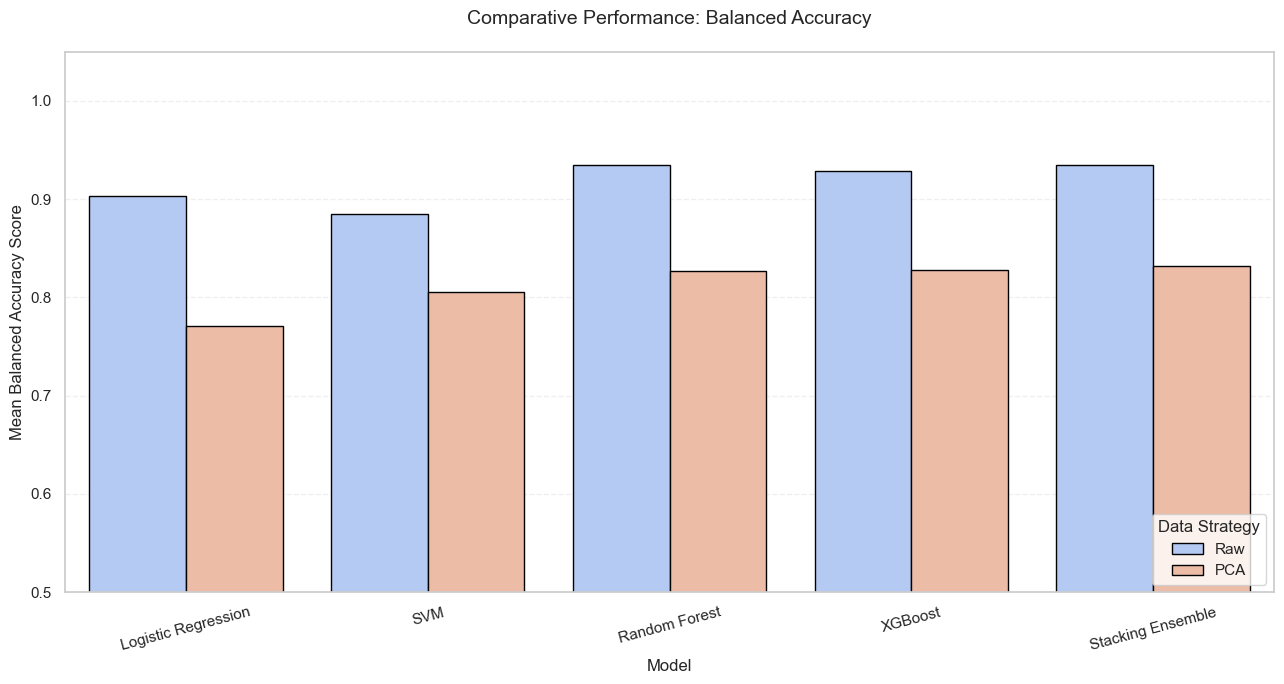

In [6]:
# SEKCJA 6: NAUKOWA WALIDACJA PORÓWNAWCZA

from xgboost import XGBClassifier

# 1. Konfiguracja
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM': SVC(probability=True, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_SEED),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_SEED),
    'Stacking Ensemble': get_stacking_ensemble()
}

cv_groups = df[next((col for col in ['Source_File', 'File', 'Motor_ID', 'ID'] if col in df.columns), None)] if 'Source_File' in df.columns else None
results = []

print("Running 5-Fold Stratified Group Cross-Validation...")

for name, clf in models.items():
    for use_pca in [False, True]:
        variant = "PCA" if use_pca else "Raw"
        metrics = evaluate_model(clf, X, y_encoded, groups=cv_groups, use_pca=use_pca, select_features=True)
        
        for m_name in ["BACC", "F1"]:
            results.append({
                "Model": name, "Variant": variant, "Metric": m_name,
                "Mean": metrics[f"{m_name}_mean"], "Std": metrics[f"{m_name}_std"]
            })
        print(f"Completed: {name} | Variant: {variant}")

# 2. Macierz wyników
df_res = pd.DataFrame(results)
df_res["Display"] = df_res.apply(lambda x: f"{x['Mean']:.3f} ± {x['Std']:.3f}", axis=1)

scientific_matrix = df_res.pivot(index=["Model", "Variant"], columns="Metric", values="Display")[["F1", "BACC"]]

# 3. Obliczanie roznicy
bacc_pivot = df_res[df_res["Metric"] == "BACC"].pivot(index="Model", columns="Variant", values="Mean")
f1_pivot = df_res[df_res["Metric"] == "F1"].pivot(index="Model", columns="Variant", values="Mean")

delta_matrix = pd.DataFrame({
    "delta_bacc (pp)": (bacc_pivot["Raw"] - bacc_pivot["PCA"]) * 100,
    "delta_macro_f1 (pp)": (f1_pivot["Raw"] - f1_pivot["PCA"]) * 100
})

print(scientific_matrix)
print("\nPCA PERFORMANCE IMPACT (Delta Raw - PCA):")
print(delta_matrix.map(lambda x: f"{x:+.2f}%".replace('+', '+ ')))

# 4. Wizualizacja
plt.figure(figsize=(13, 7))
sns.barplot(
    data=df_res[df_res["Metric"] == "BACC"], 
    x="Model", y="Mean", hue="Variant", 
    palette="coolwarm", edgecolor='black', capsize=.1
)
plt.title("Comparative Performance: Balanced Accuracy", fontsize=14, pad=20)
plt.ylabel("Mean Balanced Accuracy Score", fontsize=12)
plt.ylim(0.5, 1.05)
plt.legend(title="Data Strategy", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("performance_comparison.png", dpi=200)
plt.show()

scientific_matrix.to_csv("final_results_matrix.csv")

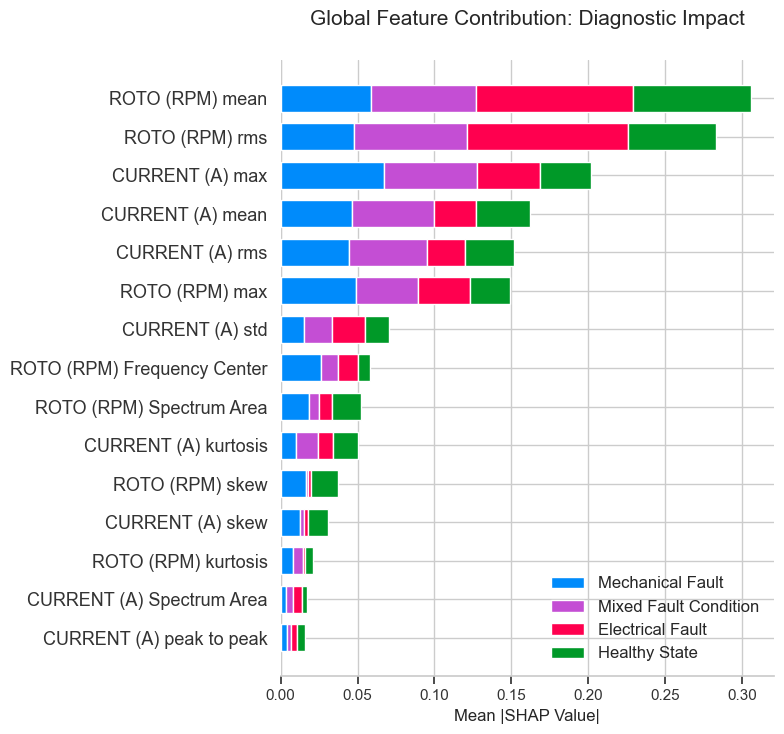

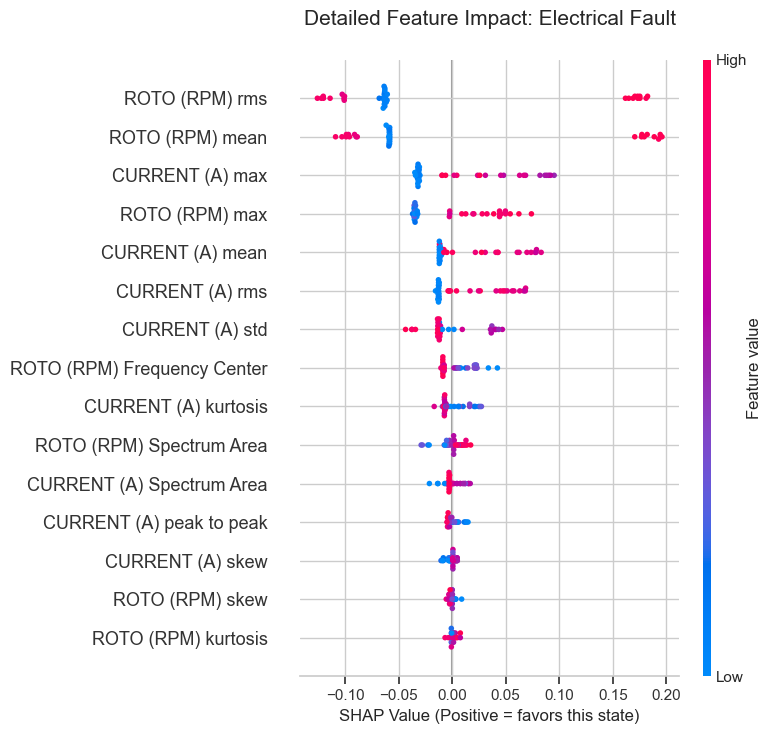

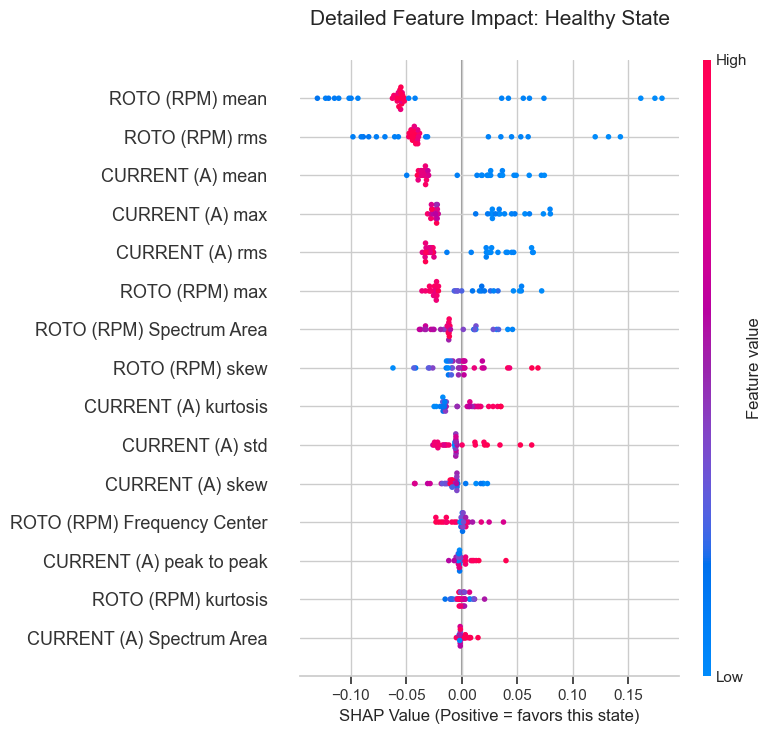

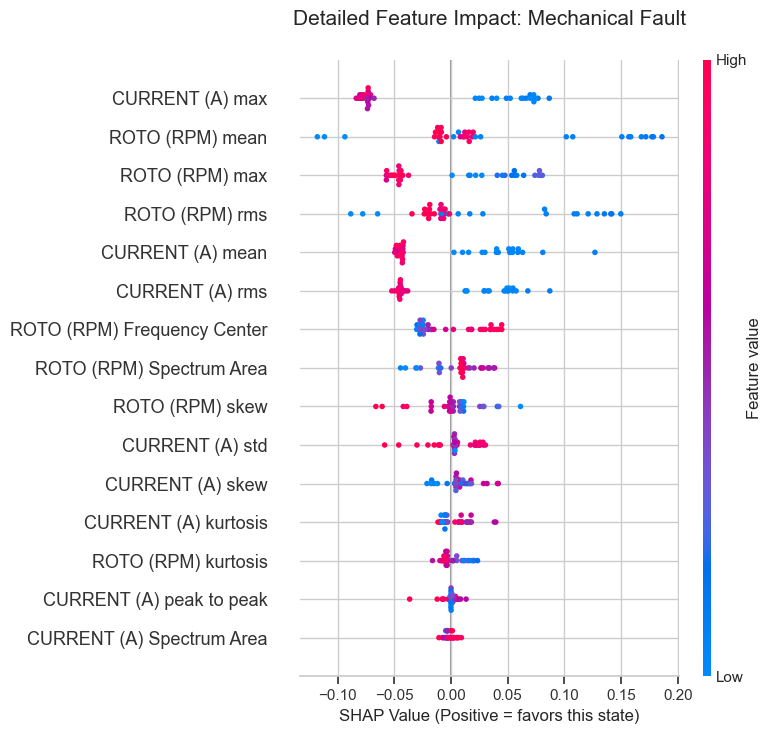

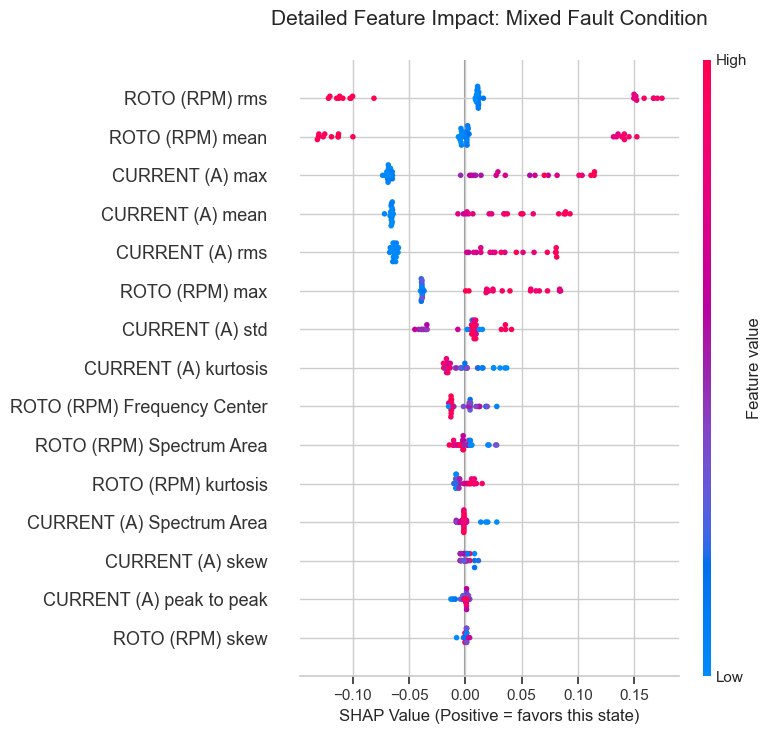

In [9]:
# SEKCJA 7: ANALIZA SHAP – INTERPRETACJA DECYZJI MODELU

import shap
from sklearn.model_selection import GroupShuffleSplit

# 1. Przygotowanie danych Top 15 cech 
top_15_features = importances.head(15)['Feature'].tolist()
X_shap = X[top_15_features].copy()
X_shap.columns = [col.replace('_', ' ') for col in X_shap.columns]

# Wykrywanie kolumny grupującej
group_col = next((col for col in ['Source_File', 'File', 'Motor_ID', 'ID'] if col in df.columns), None)

# 2. Podział na zbior treningowy i testowy
if group_col:
    gss_sh = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)
    train_idx, test_idx = next(gss_sh.split(X_shap, y_encoded, groups=df[group_col]))
else:
    skf_sh = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    train_idx, test_idx = next(skf_sh.split(X_shap, y_encoded))

X_train_sh, X_test_sh = X_shap.iloc[train_idx], X_shap.iloc[test_idx]
y_train_sh, y_test_sh = y_encoded[train_idx], y_encoded[test_idx]

# 3. Trening modelu do interpretacji
model_for_shap = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_SEED, n_jobs=-1)
model_for_shap.fit(X_train_sh, y_train_sh)

# 4. Obliczanie wartosci SHAP
explainer = shap.TreeExplainer(model_for_shap)
shap_values = explainer.shap_values(X_test_sh, check_additivity=False)
shap_values_plot = shap_values if isinstance(shap_values, list) else [shap_values[:, :, i] for i in range(shap_values.shape[2])]

# 5. Wizualiacja ogólna
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_plot, X_test_sh, class_names=class_names, plot_type="bar", show=False)
plt.title("Global Feature Contribution: Diagnostic Impact", fontsize=15, pad=25)
plt.xlabel("Mean |SHAP Value|", fontsize=12)
plt.tight_layout()
plt.savefig("shap_global_contribution.png", dpi=200)
plt.show()

# 6. Wizualizacja szczegółowa (beeswarm)
for class_idx, class_name in enumerate(class_names):
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_plot[class_idx], X_test_sh, show=False)
    plt.title(f"Detailed Feature Impact: {class_name}", fontsize=15, pad=25)
    plt.xlabel("SHAP Value (Positive = favors this state)", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"shap_beeswarm_{class_name.replace(' ', '_').lower()}.png", dpi=200)
    plt.show()

Modality: Current Signal Only       | Strategy: Raw Features    | BAcc: 89.39%
Modality: Current Signal Only       | Strategy: With PCA        | BAcc: 73.50%
Modality: Rotational Signal Only    | Strategy: Raw Features    | BAcc: 95.17%
Modality: Rotational Signal Only    | Strategy: With PCA        | BAcc: 85.50%
Modality: Data Fusion (Combined)    | Strategy: Raw Features    | BAcc: 95.72%
Modality: Data Fusion (Combined)    | Strategy: With PCA        | BAcc: 84.28%
Strategy                   Raw Features         With PCA
Modality                                                
Current Signal Only     0.8939 ± 0.0303  0.7350 ± 0.0603
Data Fusion (Combined)  0.9572 ± 0.0278  0.8428 ± 0.0722
Rotational Signal Only  0.9517 ± 0.0270  0.8550 ± 0.0421


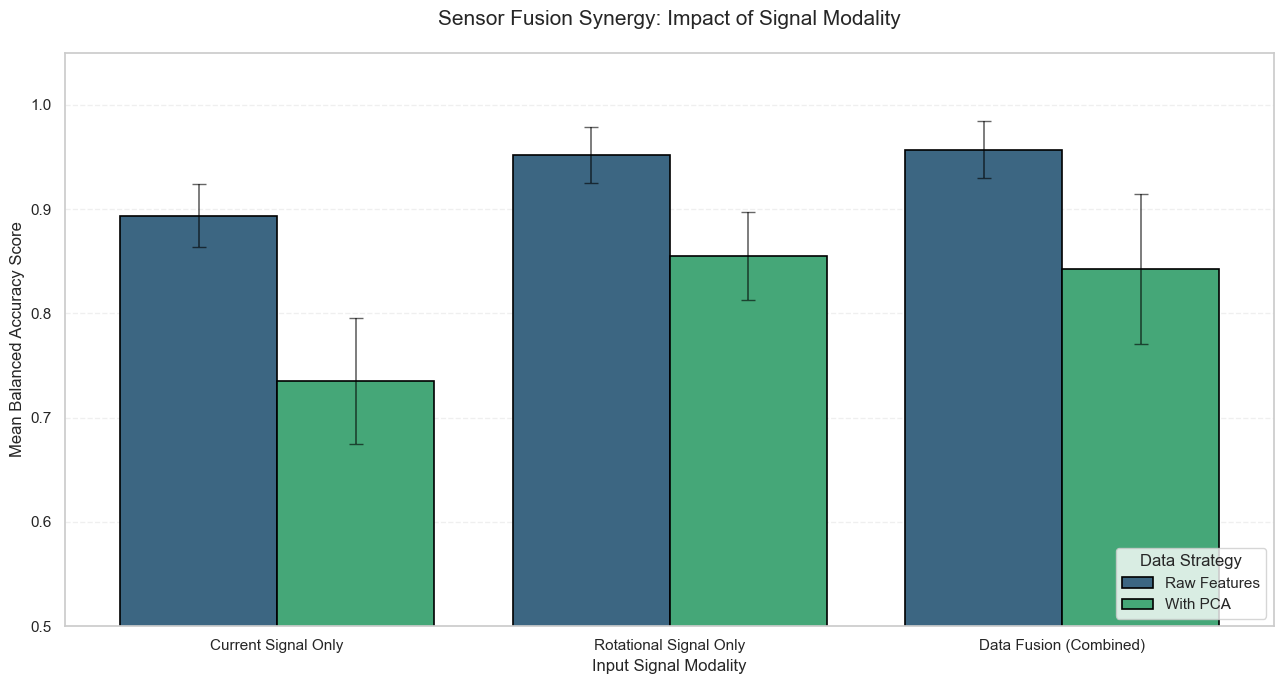

In [14]:
# SEKCJA 8: ANALIZA MODALNOŚCI I FUZJI DANYCH

# 1. Definicja scenariuszy modalności
modalities = {
    "Current Signal Only": [c for c in feature_cols if "CURRENT" in c.upper()],
    "Rotational Signal Only": [c for c in feature_cols if "ROTO" in c.upper()],
    "Data Fusion (Combined)": feature_cols 
}

results_fusion = []

# 2. Ewaluacja modeli dla różnych modalności
for name, f_list in modalities.items():
    for use_pca in [False, True]:
        variant_label = "With PCA" if use_pca else "Raw Features"
        
        metrics = evaluate_model(get_stacking_ensemble(), X[f_list], y_encoded, 
                                groups=cv_groups, use_pca=use_pca, select_features=False)
        
        results_fusion.append({
            "Modality": name,
            "Strategy": variant_label,
            "BAcc_Mean": metrics["BACC_mean"],
            "BAcc_Std": metrics["BACC_std"]
        })
        
        print(f"Modality: {name:<25} | Strategy: {variant_label:<15} | BAcc: {metrics['BACC_mean']:.2%}")

# 3. Generowanie tabeli wyników
df_fusion = pd.DataFrame(results_fusion)
df_fusion["Display"] = df_fusion.apply(lambda x: f"{x['BAcc_Mean']:.4f} ± {x['BAcc_Std']:.4f}", axis=1)

fusion_matrix = df_fusion.pivot(index="Modality", columns="Strategy", values="Display")

print(fusion_matrix)

# 4. Wizualizacja wpływu fuzji danych
plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=df_fusion, 
    x="Modality", 
    y="BAcc_Mean", 
    hue="Strategy", 
    palette="viridis", 
    edgecolor='black', 
    linewidth=1.2
)

x_pos = [i + offset for i in range(len(modalities)) for offset in [-0.2, 0.2]]
plt.errorbar(
    x=x_pos, 
    y=df_fusion['BAcc_Mean'], 
    yerr=df_fusion['BAcc_Std'], 
    fmt='none', c='black', capsize=5, elinewidth=1.2, alpha=0.6
)

plt.ylim(0.5, 1.05)
plt.title("Sensor Fusion Synergy: Impact of Signal Modality", fontsize=15, pad=20)
plt.ylabel("Mean Balanced Accuracy Score", fontsize=12)
plt.xlabel("Input Signal Modality", fontsize=12)
plt.legend(title="Data Strategy", loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("sensor_fusion_synergy.png", dpi=200)
plt.show()